In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (classification_report, accuracy_score, confusion_matrix, 
                             ConfusionMatrixDisplay, balanced_accuracy_score)
import pickle
from datetime import datetime
import time
import json
import warnings
warnings.filterwarnings('ignore')

# Set plotting style to display inline in Jupyter
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

1. DATASET OVERVIEW & TARGET DISTRIBUTION
Dataset shape: 100 rows × 8 columns



,age,weight,height,income_lpa,smoker,city,occupation,insurance_premium_category
0,67,119.8,1.56,2.92,False,Jaipur,retired,High
1,36,101.1,1.83,34.28,False,Chennai,freelancer,Low
2,39,56.8,1.64,36.64,False,Indore,freelancer,Low
3,22,109.4,1.55,3.34,True,Mumbai,student,Medium
4,69,62.2,1.60,3.94,True,Indore,retired,High



Missing values:
age                           0
weight                        0
height                        0
income_lpa                    0
smoker                        0
city                          0
occupation                    0
insurance_premium_category    0
dtype: int64

Class distribution (%):


insurance_premium_category
Low       34.0
High      33.0
Medium    33.0
Name: proportion, dtype: float64

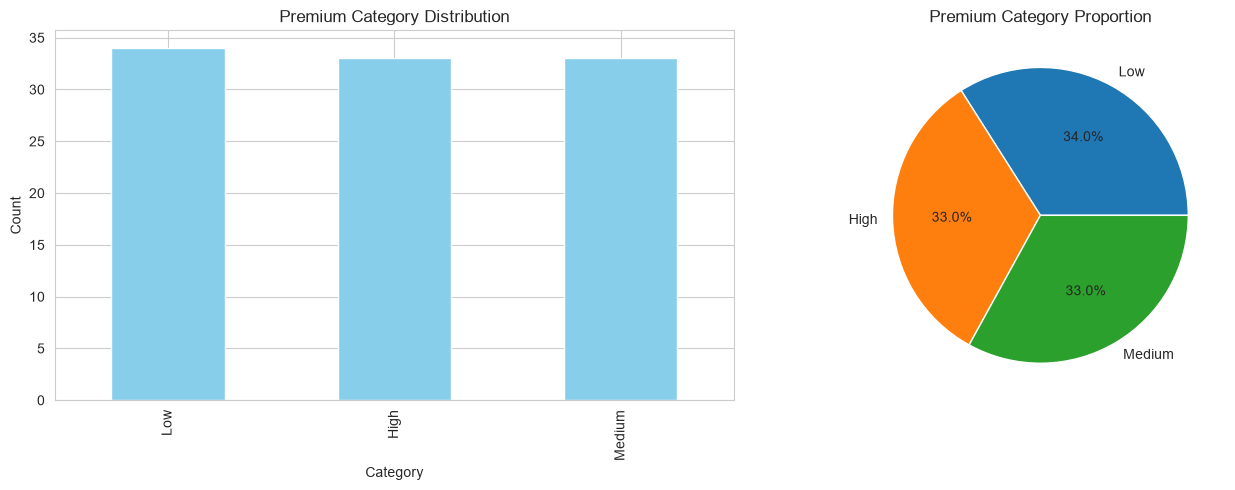

In [2]:
# Load dataset
df = pd.read_csv('insurance.csv')

print("="*60)
print("1. DATASET OVERVIEW & TARGET DISTRIBUTION")
print("="*60)
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns\n")

# Added df.head() for interactive notebook viewing
display(df.head())

print(f"\nMissing values:\n{df.isnull().sum()}")

print("\nClass distribution (%):")
display(df['insurance_premium_category'].value_counts(normalize=True) * 100)

# Visualize target distribution (Will render directly in your notebook)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
df['insurance_premium_category'].value_counts().plot(kind='bar', ax=ax[0], color='skyblue')
ax[0].set_title('Premium Category Distribution')
ax[0].set_xlabel('Category')
ax[0].set_ylabel('Count')

df['insurance_premium_category'].value_counts(normalize=True).plot(kind='pie', ax=ax[1], autopct='%1.1f%%')
ax[1].set_title('Premium Category Proportion')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

2. EXPLORATORY DATA ANALYSIS


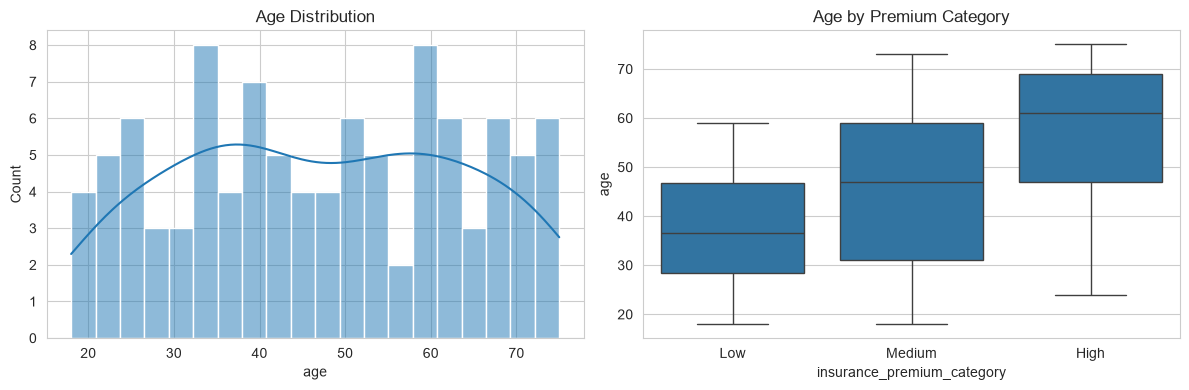

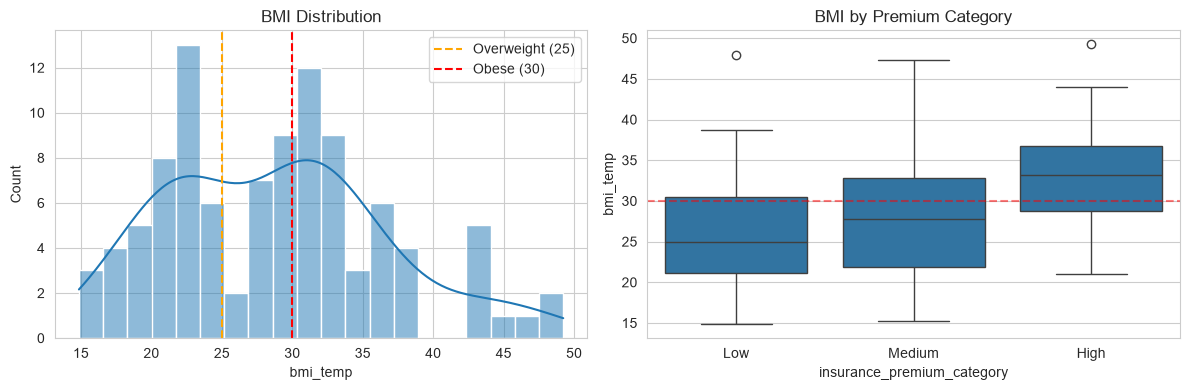

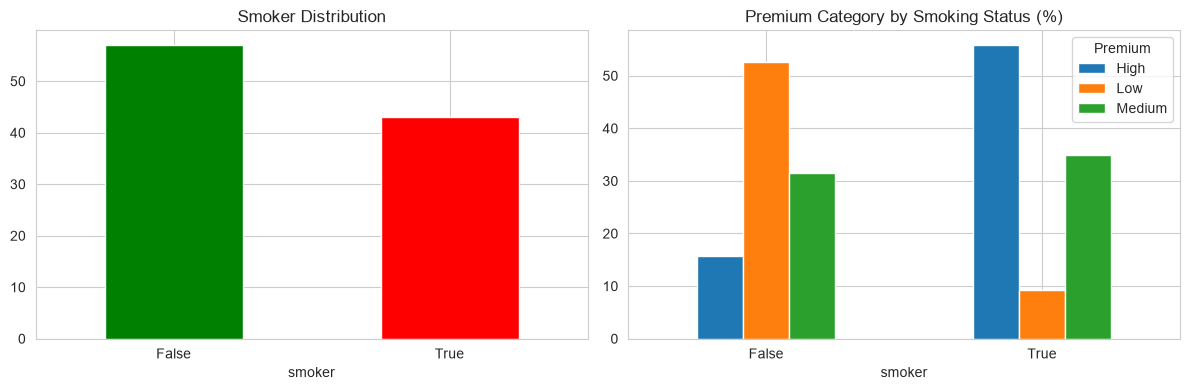

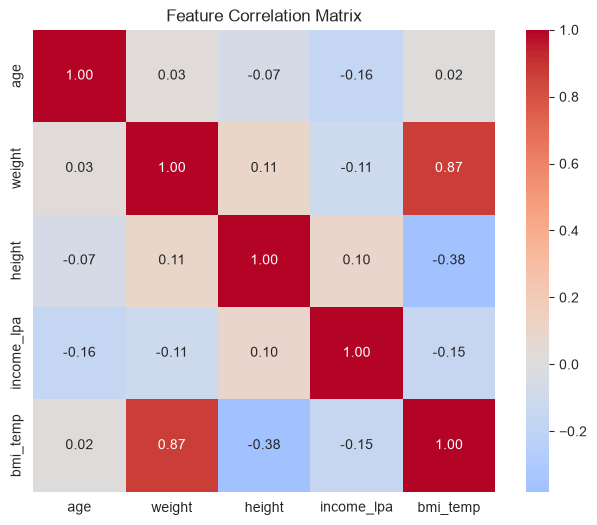

In [3]:
print("="*60)
print("2. EXPLORATORY DATA ANALYSIS")
print("="*60)

# 1. Age distribution
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='age', bins=20, kde=True)
plt.title('Age Distribution')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='insurance_premium_category', y='age', order=['Low', 'Medium', 'High'])
plt.title('Age by Premium Category')
plt.tight_layout()
plt.show()

# 2. BMI calculation and analysis
df['bmi_temp'] = df['weight'] / (df['height'] ** 2)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(data=df, x='bmi_temp', bins=20, kde=True)
plt.axvline(x=25, color='orange', linestyle='--', label='Overweight (25)')
plt.axvline(x=30, color='red', linestyle='--', label='Obese (30)')
plt.title('BMI Distribution')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='insurance_premium_category', y='bmi_temp', order=['Low', 'Medium', 'High'])
plt.axhline(y=30, color='red', linestyle='--', alpha=0.5)
plt.title('BMI by Premium Category')
plt.tight_layout()
plt.show()

# 3. Smoking impact
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
df['smoker'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title('Smoker Distribution')
plt.xticks(rotation=0)

plt.subplot(1, 2, 2)
smoker_premium = pd.crosstab(df['smoker'], df['insurance_premium_category'], normalize='index') * 100
smoker_premium.plot(kind='bar', stacked=False, ax=plt.gca())
plt.title('Premium Category by Smoking Status (%)')
plt.legend(title='Premium')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. Correlation heatmap
plt.figure(figsize=(8, 6))
numerical_cols = ['age', 'weight', 'height', 'income_lpa', 'bmi_temp']
sns.heatmap(df[numerical_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix')
plt.show()

In [4]:
print("="*60)
print("3. FEATURE ENGINEERING & DATA PREPARATION")
print("="*60)

df_feat = df.copy()

# Feature 1: BMI
df_feat["bmi"] = df_feat["weight"] / (df_feat["height"] ** 2)

# Feature 2: Age Group
def age_group(age):
    if age < 25: return "young"
    elif age < 45: return "adult"
    elif age < 60: return "middle_aged"
    return "senior"
df_feat["age_group"] = df_feat["age"].apply(age_group)

# Feature 3: Lifestyle Risk
def lifestyle_risk(row):
    if row["smoker"] and row["bmi"] > 30: return "high"
    elif row["smoker"] or row["bmi"] > 27: return "medium"
    return "low"
df_feat["lifestyle_risk"] = df_feat.apply(lifestyle_risk, axis=1)

# Feature 4: City Tier
tier_1_cities = ["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata", "Hyderabad", "Pune"]
tier_2_cities = ["Jaipur", "Chandigarh", "Indore", "Lucknow", "Patna", "Ranchi", "Visakhapatnam", "Coimbatore"] # truncated list for readability

def city_tier(city):
    if city in tier_1_cities: return 1
    elif city in tier_2_cities: return 2
    return 3
df_feat["city_tier"] = df_feat["city"].apply(city_tier)

# Select features and target
X = df_feat[["bmi", "age_group", "lifestyle_risk", "city_tier", "income_lpa", "occupation"]]
y = df_feat["insurance_premium_category"]

print("✓ Feature Engineering Complete.")
print(f"Features selected for modeling: {list(X.columns)}")
display(X.head())

3. FEATURE ENGINEERING & DATA PREPARATION
✓ Feature Engineering Complete.
Features selected for modeling: ['bmi', 'age_group', 'lifestyle_risk', 'city_tier', 'income_lpa', 'occupation']


,bmi,age_group,lifestyle_risk,city_tier,income_lpa,occupation
0,49.227482,senior,medium,2,2.92,retired
1,30.189017,adult,medium,1,34.28,freelancer
2,21.118382,adult,low,2,36.64,freelancer
3,45.535900,young,high,1,3.34,student
4,24.296875,senior,medium,2,3.94,retired


In [8]:
print("="*60)
print("4. PIPELINE CREATION & STRATIFIED SPLIT")
print("="*60)

categorical_features = ["age_group", "lifestyle_risk", "occupation", "city_tier"]
numeric_features = ["bmi", "income_lpa"]

# Preprocessing Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

# Baseline Random Forest Pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

# Stratified Split (keeps class percentages identical in train and test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples\n")
print("Train Class Split (%):\n", y_train.value_counts(normalize=True)*100)

4. PIPELINE CREATION & STRATIFIED SPLIT
Training set size: 80 samples
Test set size: 20 samples

Train Class Split (%):
 insurance_premium_category
High      33.75
Low       33.75
Medium    32.50
Name: proportion, dtype: float64


5. BASELINE MODEL TRAINING & EVALUATION
✓ Model trained in 0.68 seconds

Training Accuracy: 100.00%
Test Accuracy:     70.00%
Overfitting Gap:   30.00%

Classification Report:
              precision    recall  f1-score   support

        High       0.67      0.67      0.67         6
         Low       0.70      1.00      0.82         7
      Medium       0.75      0.43      0.55         7

    accuracy                           0.70        20
   macro avg       0.71      0.70      0.68        20
weighted avg       0.71      0.70      0.68        20



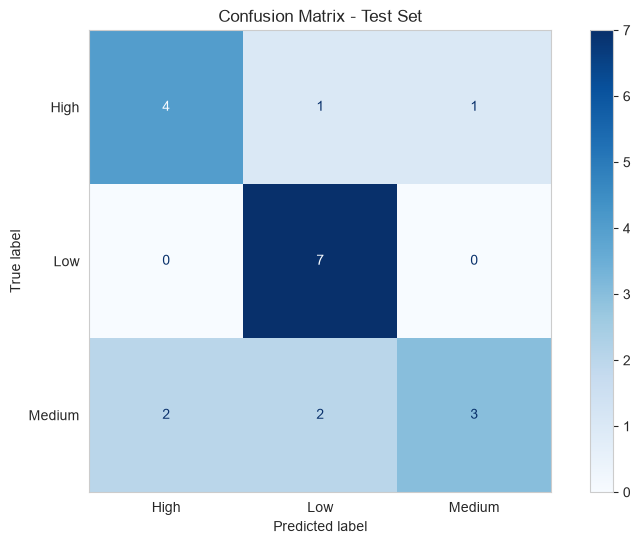

In [11]:
print("="*60)
print("5. BASELINE MODEL TRAINING & EVALUATION")
print("="*60)

# Train
start_time = time.time()
pipeline.fit(X_train, y_train)
print(f"✓ Model trained in {time.time() - start_time:.2f} seconds\n")

# Predict
y_pred = pipeline.predict(X_test)
y_pred_train = pipeline.predict(X_train)

# Evaluate Accuracies
train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Training Accuracy: {train_accuracy*100:.2f}%")
print(f"Test Accuracy:     {test_accuracy*100:.2f}%")
print(f"Overfitting Gap:   {(train_accuracy - test_accuracy)*100:.2f}%\n")

# Detailed Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['High', 'Low', 'Medium']))

# Confusion Matrix Visual
cm = confusion_matrix(y_test, y_pred, labels=['High', 'Low', 'Medium'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['High', 'Low', 'Medium'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Test Set')
plt.grid(False)
plt.show()

6. ALGORITHM COMPARISON (5-FOLD CROSS-VALIDATION)
Random Forest       : Mean Accuracy = 78.00% (± 9.27%)
Logistic Regression : Mean Accuracy = 75.00% (± 6.32%)
SVM                 : Mean Accuracy = 45.00% (± 10.49%)
Gradient Boosting   : Mean Accuracy = 64.00% (± 9.70%)


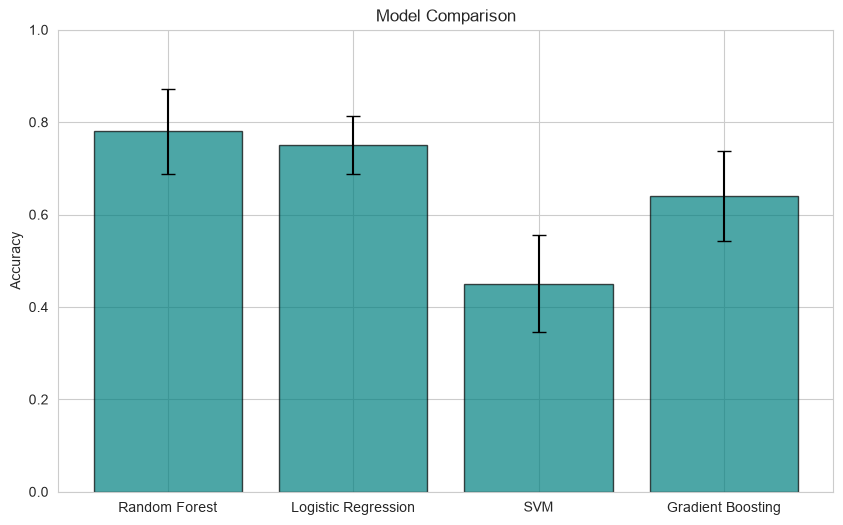

In [12]:
print("="*60)
print("6. ALGORITHM COMPARISON (5-FOLD CROSS-VALIDATION)")
print("="*60)

models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

results = {}
for name, classifier in models.items():
    pipe_temp = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", classifier)])
    scores = cross_val_score(pipe_temp, X, y, cv=5, scoring='accuracy')
    results[name] = {'mean': scores.mean(), 'std': scores.std()}
    print(f"{name:20s}: Mean Accuracy = {scores.mean()*100:.2f}% (± {scores.std()*100:.2f}%)")

# Plot Comparison
names = list(results.keys())
means = [results[name]['mean'] for name in names]
stds = [results[name]['std'] for name in names]

plt.bar(names, means, yerr=stds, capsize=5, alpha=0.7, color='teal', edgecolor='black')
plt.ylabel('Accuracy')
plt.title('Model Comparison')
plt.ylim(0, 1.0)
plt.show()

In [14]:
print("="*60)
print("9. REGULARIZED HYPERPARAMETER TUNING")
print("="*60)

# We force the model to look at larger groups of samples
param_grid_restricted = {
    'classifier__n_estimators': [100, 150],
    'classifier__max_depth': [3, 4, 5],               # Cap tree depth so it can't memorize specific rows
    'classifier__min_samples_leaf': [3, 5, 7],         # Forces a leaf to have at least X samples to make a choice
    'classifier__max_features': ['sqrt', None]         # Limit features per split
}

grid_search_fixed = GridSearchCV(
    pipeline, 
    param_grid_restricted, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1
)
grid_search_fixed.fit(X_train, y_train)

print(f"✓ New Regularized Parameters: {grid_search_fixed.best_params_}")

# Re-evaluate
best_pipe_fixed = grid_search_fixed.best_estimator_
y_pred_new = best_pipe_fixed.predict(X_test)
y_pred_train_new = best_pipe_fixed.predict(X_train)

print(f"\nNew Training Accuracy: {accuracy_score(y_train, y_pred_train_new)*100:.2f}%")
print(f"New Test Accuracy:     {accuracy_score(y_test, y_pred_new)*100:.2f}%")
print(f"New Overfitting Gap:   {(accuracy_score(y_train, y_pred_train_new) - accuracy_score(y_test, y_pred_new))*100:.2f}%")
plt.show()

9. REGULARIZED HYPERPARAMETER TUNING
✓ New Regularized Parameters: {'classifier__max_depth': 4, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 3, 'classifier__n_estimators': 100}

New Training Accuracy: 93.75%
New Test Accuracy:     65.00%
New Overfitting Gap:   28.75%
